In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import warnings
from scipy.optimize import curve_fit

### Distribution Functions

In [2]:
def gaussian_pdf(D, mu, sigma):
    D = np.asarray(D, dtype=float)
    pdf = np.exp(-0.5 * ((D - mu) / sigma) ** 2)
    pdf[D <= 0] = 0.0
    return pdf


def normalize_pdf(D, pdf):
    Z = np.trapezoid(pdf, D)
    if Z <= 0:
        raise ValueError("Normalization constant is non-positive.")
    return pdf / Z, Z

In [3]:
def build_gaussian_distribution(mu_D, sigma_D, n_sigma=6, min_points=2000):
    D_min = max(0.0, mu_D - n_sigma * sigma_D)
    D_max = mu_D + n_sigma * sigma_D
    width = D_max - D_min

    n_points = int(200 * width / sigma_D)
    n_points = max(n_points, min_points)

    D_grid = np.linspace(D_min, D_max, n_points)
    P_gaus = gaussian_pdf(D_grid, mu_D, sigma_D)
    P_grid, Z = normalize_pdf(D_grid, P_gaus)

    return {
        "D_grid": D_grid,
        "P_grid": P_grid,
        "Z": Z,
        "mu_D": mu_D,
        "sigma_D": sigma_D,
    }

### Simulation Functions

In [4]:
def simulation(D_grid, P_grid, q_vals, t_vals):
    """
    Simulate f(q,t) = ∫ P(D) exp(-D q^2 t) dD
    Returns array of shape (len(q_vals), len(t_vals))
    """
    Nq = len(q_vals)
    Nt = len(t_vals)
    f = np.empty((Nq, Nt), dtype=float)

    for i, q in enumerate(q_vals):
        qq = q * q
        for j, t in enumerate(t_vals):
            integrand = P_grid * np.exp(-D_grid * qq * t)
            f[i, j] = np.trapezoid(integrand, D_grid)

    return f


def add_ddm_like_noise(f_mat, alpha=0.25, N_eff=500, seed=42):
    """
    Add heteroscedastic Gaussian additive noise:
        sigma_f = alpha * sqrt((1 - f^2)/N_eff)
    """
    rng = np.random.default_rng(seed)
    sigma_f = alpha * np.sqrt(np.clip(1.0 - f_mat**2, 0.0, None) / N_eff)
    noise = rng.normal(loc=0.0, scale=sigma_f, size=f_mat.shape)
    f_noisy = np.clip(f_mat + noise, 1e-8, 1.0)

    return {
        "f_noisy": f_noisy,
        "sigma_f": sigma_f,
        "alpha": alpha,
        "N_eff": N_eff,
        "seed": seed,
    }

### Parameters

In [5]:
# True distribution parameters
mu_D = 2.0
sigma_D = 0.4

# q and t grids
q_vals = np.linspace(0.5, 3.0, 25)
t_vals = np.logspace(np.log10(1e-3), np.log10(200), 200)

# Noise model
alpha = 0.2
N_eff = 500

#### Generation of data

In [6]:
dist = build_gaussian_distribution(mu_D=mu_D, sigma_D=sigma_D)
D_grid = dist["D_grid"]
P_grid = dist["P_grid"]

f_mat = simulation(D_grid, P_grid, q_vals, t_vals)

noise_out = add_ddm_like_noise(f_mat, alpha=alpha, N_eff=N_eff, seed=42)
f_noisy = noise_out["f_noisy"]
sigma_f_mat = noise_out["sigma_f"]

In [7]:
def plot_true_distribution(D_grid, P_grid):
    plt.figure()
    plt.plot(D_grid, P_grid, linewidth=2)
    plt.xlabel("D")
    plt.ylabel("P(D)")
    plt.title("True distribution")
    plt.show()


def plot_sample_isf(q_vals, t_vals, f_mat, title="ISF", n_show=3):
    plt.figure()

    indices = [0, len(q_vals)//2, len(q_vals)-1][:n_show]
    for i in indices:
        plt.semilogx(t_vals, f_mat[i], label=f"q={q_vals[i]:.2f}")

    plt.xlabel("t")
    plt.ylabel("f(q,t)")
    plt.title(title)
    plt.legend()
    plt.show()

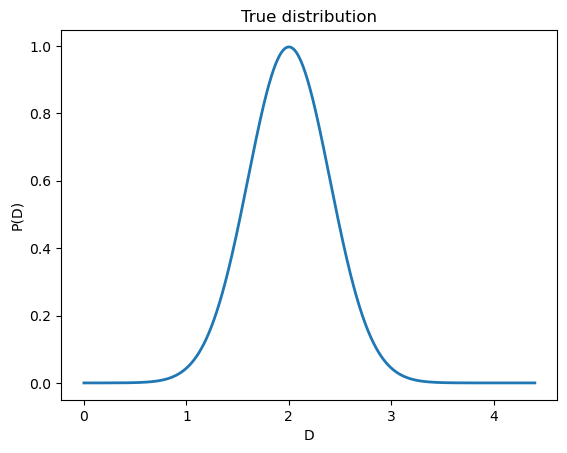

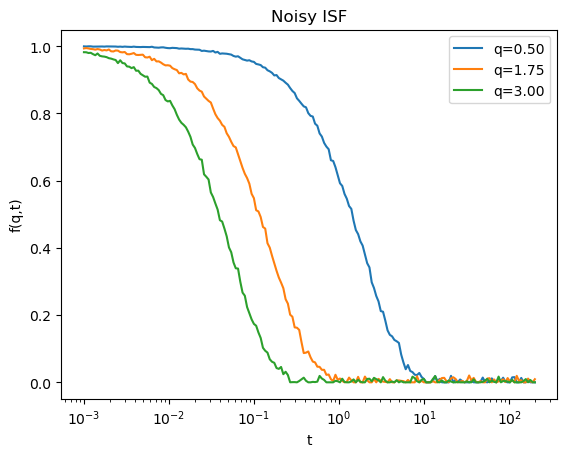

In [8]:
plot_true_distribution(D_grid, P_grid)
plot_sample_isf(q_vals, t_vals, f_noisy, title="Noisy ISF")

## Linear Cumulant Method Functions

In [9]:
def make_cumulant_function(n_cumulants):
    """
    Model for ln f(x):
        ln f(x) = sum_{n=1}^N (-1)^n mu_n x^n / n!
    """
    if n_cumulants > 4:
        warnings.warn(
            f"Using more than 4 cumulants (n={n_cumulants}) may lead to instabilities.",
            UserWarning
        )

    def cumulant_func(x, *params):
        x = np.asarray(x, dtype=float)
        ln_f = np.zeros_like(x, dtype=float)

        for n, mu_n in enumerate(params, start=1):
            ln_f += ((-1) ** n) * mu_n * (x ** n) / math.factorial(n)

        return ln_f

    return cumulant_func


def collapse_data_linear(q_vals, t_vals, f_mat, f_min=0.05, f_max=1.0):
    x_data = []
    y_data = []

    for i, q in enumerate(q_vals):
        qq = q * q
        for j, t in enumerate(t_vals):
            f = f_mat[i, j]
            if np.isfinite(f) and (f_min <= f <= f_max):
                x_data.append(qq * t)
                y_data.append(np.log(f))

    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    order = np.argsort(x_data)
    return x_data[order], y_data[order]


def fit_cumulants_linear(
    q_vals,
    t_vals,
    f_mat,
    n_cumulants=3,
    f_min=0.05,
    f_max=1.0,
    maxfev=20000,
):
    x_data, y_data = collapse_data_linear(
        q_vals, t_vals, f_mat, f_min=f_min, f_max=f_max
    )

    if x_data.size == 0:
        raise ValueError("No data points available in the selected [f_min, f_max] range.")

    model = make_cumulant_function(n_cumulants)

    p0 = [1.0] + [0.0] * (n_cumulants - 1)

    lower_bounds = [0.0] * min(n_cumulants, 2) + [-np.inf] * max(0, n_cumulants - 2)
    upper_bounds = [np.inf] * n_cumulants

    params, cov = curve_fit(
        model,
        x_data,
        y_data,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev=maxfev,
    )

    y_fit = model(x_data, *params)
    rmse = np.sqrt(np.mean((y_data - y_fit) ** 2))

    return {
        "method": "linear",
        "params": params,
        "cov": cov,
        "x_data": x_data,
        "y_data": y_data,
        "y_fit": y_fit,
        "rmse": rmse,
        "f_min": f_min,
        "f_max": f_max,
        "n_cumulants": n_cumulants,
        "model": model,
    }

## Nonlinear Cumulant Method Functions

In [10]:
def make_nonlinear_cumulant_function(n_cumulants):
    """
    Model for f(x):
        f(x) = exp(-mu1*x) * [1 + mu2*x^2/2! - mu3*x^3/3! + ...]
    """
    if n_cumulants > 4:
        warnings.warn(
            f"Using more than 4 cumulants/moments (n={n_cumulants}) may lead to instabilities.",
            UserWarning
        )

    def nonlinear_model(x, *params):
        x = np.asarray(x, dtype=float)

        if len(params) != n_cumulants:
            raise ValueError(
                f"Expected {n_cumulants} parameters, got {len(params)}."
            )

        mu1 = params[0]
        correction = np.ones_like(x, dtype=float)

        for n, mu_n in enumerate(params[1:], start=2):
            correction += ((-1) ** n) * mu_n * (x ** n) / math.factorial(n)

        return np.exp(-mu1 * x) * correction

    return nonlinear_model


def collapse_data_nonlinear(q_vals, t_vals, f_mat, f_min=0.0, f_max=1.0):
    x_data = []
    y_data = []

    for i, q in enumerate(q_vals):
        qq = q * q
        for j, t in enumerate(t_vals):
            f = f_mat[i, j]
            if np.isfinite(f) and (f_min <= f <= f_max):
                x_data.append(qq * t)
                y_data.append(f)

    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    order = np.argsort(x_data)
    return x_data[order], y_data[order]


def fit_cumulants_nonlinear(
    q_vals,
    t_vals,
    f_mat,
    n_cumulants=3,
    f_min=0.0,
    f_max=1.0,
    sigma=None,
    absolute_sigma=False,
    maxfev=20000,
):
    x_data, y_data = collapse_data_nonlinear(
        q_vals, t_vals, f_mat, f_min=f_min, f_max=f_max
    )

    if x_data.size == 0:
        raise ValueError("No data points available in the selected [f_min, f_max] range.")

    model = make_nonlinear_cumulant_function(n_cumulants)

    p0 = [1.0] + [0.0] * (n_cumulants - 1)

    lower_bounds = [0.0] * min(n_cumulants, 2) + [-np.inf] * max(0, n_cumulants - 2)
    upper_bounds = [np.inf] * n_cumulants

    if sigma is not None:
        sigma = np.asarray(sigma, dtype=float)
        if sigma.shape != y_data.shape:
            raise ValueError("sigma must have the same shape as collapsed y_data.")

    params, cov = curve_fit(
        model,
        x_data,
        y_data,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        sigma=sigma,
        absolute_sigma=absolute_sigma,
        maxfev=maxfev,
    )

    y_fit = model(x_data, *params)
    rmse = np.sqrt(np.mean((y_data - y_fit) ** 2))

    return {
        "method": "nonlinear",
        "params": params,
        "cov": cov,
        "x_data": x_data,
        "y_data": y_data,
        "y_fit": y_fit,
        "rmse": rmse,
        "f_min": f_min,
        "f_max": f_max,
        "n_cumulants": n_cumulants,
        "model": model,
    }

### Reconstruction and Summary Functions

In [11]:
def extract_mu_sigma(result):
    params = result["params"]
    mu1 = params[0]
    mu2 = params[1] if len(params) >= 2 else np.nan

    sigma = np.sqrt(mu2) if np.isfinite(mu2) and mu2 >= 0 else np.nan

    return mu1, mu2, sigma


def print_fit_summary(result, true_mu=None, true_sigma=None):
    method = result["method"]
    params = result["params"]
    cov = result["cov"]
    rmse = result["rmse"]

    mu1, mu2, sigma = extract_mu_sigma(result)

    print(f"Method: {method}")
    print(f"n_cumulants = {result['n_cumulants']}")
    print(f"f_min = {result['f_min']}")
    print(f"f_max = {result['f_max']}")
    print()

    for i, p in enumerate(params, start=1):
        print(f"mu{i} = {p}")

    print()
    print(f"sigma_rec = {sigma}")
    print(f"RMSE = {rmse}")

    if cov is not None:
        try:
            errors = np.sqrt(np.diag(cov))
            print()
            for i, err in enumerate(errors, start=1):
                print(f"err(mu{i}) = {err}")
        except Exception:
            pass

    if true_mu is not None:
        print()
        print(f"true mu = {true_mu}")
        print(f"abs error mu1 = {abs(mu1 - true_mu)}")

    if true_sigma is not None and np.isfinite(sigma):
        print(f"true sigma = {true_sigma}")
        print(f"abs error sigma = {abs(sigma - true_sigma)}")


def reconstruct_gaussian_from_result(result, D_grid=None, n_sigma=4, n_points=500):
    mu1, mu2, sigma = extract_mu_sigma(result)

    if not np.isfinite(mu1):
        raise ValueError("mu1 is not finite.")
    if not np.isfinite(mu2) or mu2 <= 0:
        raise ValueError("mu2 must be positive for Gaussian reconstruction.")

    if D_grid is None:
        D_min = max(0.0, mu1 - n_sigma * sigma)
        D_max = mu1 + n_sigma * sigma
        D_grid_rec = np.linspace(D_min, D_max, n_points)
    else:
        D_grid_rec = np.asarray(D_grid, dtype=float)

    P_rec = np.exp(-(D_grid_rec - mu1) ** 2 / (2 * mu2))
    P_rec, _ = normalize_pdf(D_grid_rec, P_rec)

    return D_grid_rec, P_rec

#### Plotting Functions

In [12]:
def plot_collapsed_fit(result):
    plt.figure()
    plt.scatter(result["x_data"], result["y_data"], s=6, alpha=0.6, label="data")

    order = np.argsort(result["x_data"])
    plt.plot(
        result["x_data"][order],
        result["y_fit"][order],
        color="red",
        linewidth=2,
        label=f"{result['method']} fit"
    )

    plt.xlabel(r"$x = q^2 t$")
    ylabel = r"$\ln f(q,t)$" if result["method"] == "linear" else r"$f(q,t)$"
    plt.ylabel(ylabel)
    plt.title(f"Collapsed data — {result['method']}")
    plt.legend()
    plt.show()


def plot_fit_vs_t(result, q_vals, t_vals, f_mat, q_list=None):
    if q_list is None:
        q_list = [q_vals[0], q_vals[len(q_vals)//2], q_vals[-1]]

    plt.figure()
    model = result["model"]
    params = result["params"]
    f_min = result["f_min"]
    f_max = result["f_max"]

    for q in q_list:
        i = np.argmin(np.abs(q_vals - q))
        q_use = q_vals[i]

        plt.semilogx(t_vals, f_mat[i], label=f"data q={q_use:.2f}")

        mask = (f_mat[i] >= f_min) & (f_mat[i] <= f_max)
        x_q = (q_use ** 2) * t_vals[mask]

        if result["method"] == "linear":
            ln_f_fit_q = model(x_q, *params)
            f_fit_q = np.exp(ln_f_fit_q)
        else:
            f_fit_q = model(x_q, *params)

        plt.semilogx(
            t_vals[mask],
            f_fit_q,
            "--",
            linewidth=2,
            label=f"{result['method']} fit q={q_use:.2f}"
        )

    plt.xlabel("t")
    plt.ylabel("f(q,t)")
    plt.title(f"Fit in time domain — {result['method']}")
    plt.legend()
    plt.show()


def plot_distribution_comparison(D_grid_true, P_grid_true, result, label=None):
    D_grid_rec, P_rec = reconstruct_gaussian_from_result(result, D_grid=D_grid_true)

    if label is None:
        label = f"{result['method']} reconstruction"

    plt.figure()
    plt.plot(D_grid_true, P_grid_true, linewidth=2, label="True distribution")
    plt.plot(D_grid_rec, P_rec, "--", linewidth=2, label=label)
    plt.xlabel("D")
    plt.ylabel("P(D)")
    plt.title(f"Distribution reconstruction — {result['method']}")
    plt.legend()
    plt.show()

### Comparation Tools Functions

In [13]:
def compare_fit_results(result_linear, result_nonlinear, true_mu=None, true_sigma=None):
    mu1_lin, mu2_lin, sigma_lin = extract_mu_sigma(result_linear)
    mu1_nl, mu2_nl, sigma_nl = extract_mu_sigma(result_nonlinear)

    rows = [
        {
            "method": "linear",
            "mu1": mu1_lin,
            "sigma": sigma_lin,
            "rmse": result_linear["rmse"],
        },
        {
            "method": "nonlinear",
            "mu1": mu1_nl,
            "sigma": sigma_nl,
            "rmse": result_nonlinear["rmse"],
        },
    ]

    df = pd.DataFrame(rows)

    if true_mu is not None:
        df["true_mu"] = true_mu
        df["abs_err_mu1"] = np.abs(df["mu1"] - true_mu)

    if true_sigma is not None:
        df["true_sigma"] = true_sigma
        df["abs_err_sigma"] = np.abs(df["sigma"] - true_sigma)

    return df

**Parameters**

In [23]:
# Fit settings
n_cumulants = 4
f_min = 0.25
f_max = 1.0

**Linear Method:**

Method: linear
n_cumulants = 4
f_min = 0.25
f_max = 1.0

mu1 = 2.0259793451611663
mu2 = 0.677674030331329
mu3 = 4.957517598617208
mu4 = 18.433444382520925

sigma_rec = 0.8232095907673386
RMSE = 0.009984985994294013

err(mu1) = 0.009720973486904257
err(mu2) = 0.17172852074608136
err(mu3) = 1.3641824923485208
err(mu4) = 4.385148386215345

true mu = 2.0
abs error mu1 = 0.02597934516116629
true sigma = 0.4
abs error sigma = 0.42320959076733855


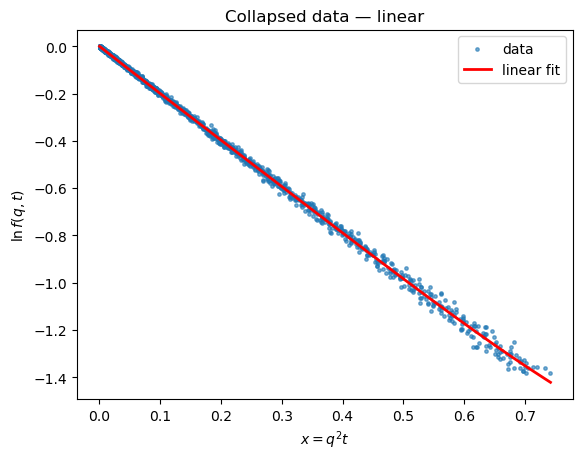

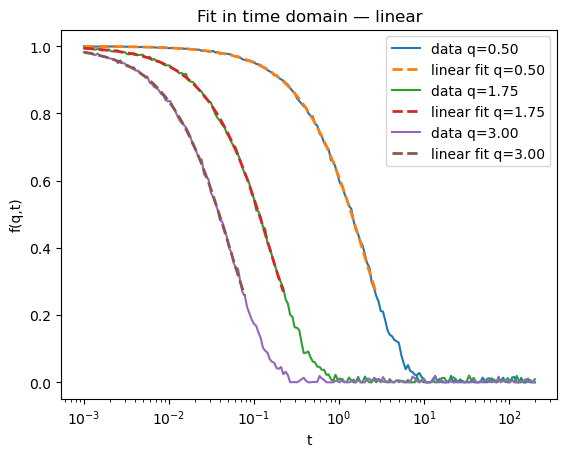

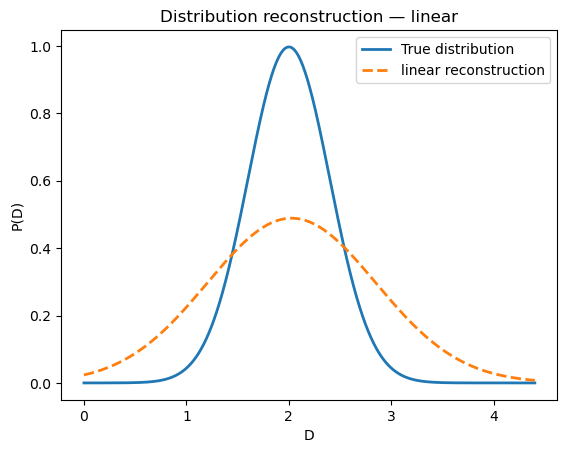

In [24]:
result_linear = fit_cumulants_linear(
    q_vals=q_vals,
    t_vals=t_vals,
    f_mat=f_noisy,
    n_cumulants=n_cumulants,
    f_min=f_min,
    f_max=f_max,
)

print_fit_summary(result_linear, true_mu=mu_D, true_sigma=sigma_D)
plot_collapsed_fit(result_linear)
plot_fit_vs_t(result_linear, q_vals, t_vals, f_noisy)
plot_distribution_comparison(D_grid, P_grid, result_linear)

Method: nonlinear
n_cumulants = 4
f_min = 0.25
f_max = 1.0

mu1 = 2.003291473612321
mu2 = 0.16418410802213848
mu3 = 0.38717500928455706
mu4 = 3.013037537897341

sigma_rec = 0.40519638204472963
RMSE = 0.004771693295816335

err(mu1) = 0.006295114955231841
err(mu2) = 0.13439772174787384
err(mu3) = 1.2307994729881182
err(mu4) = 4.42676849962626

true mu = 2.0
abs error mu1 = 0.00329147361232085
true sigma = 0.4
abs error sigma = 0.005196382044729608


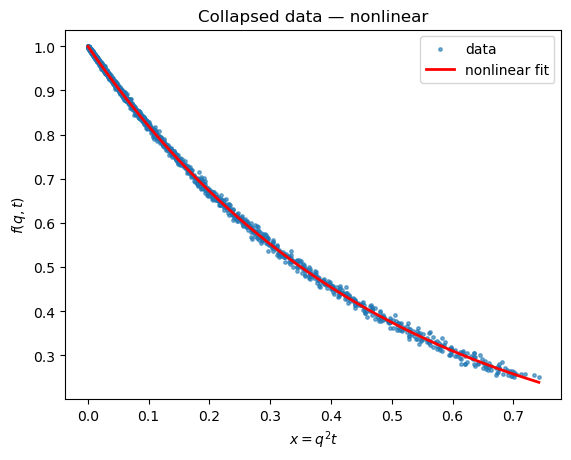

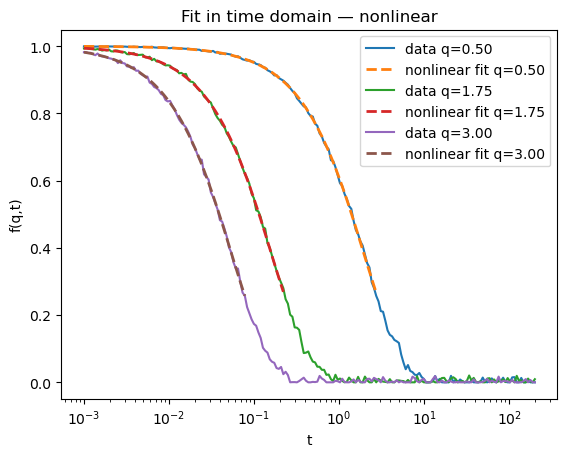

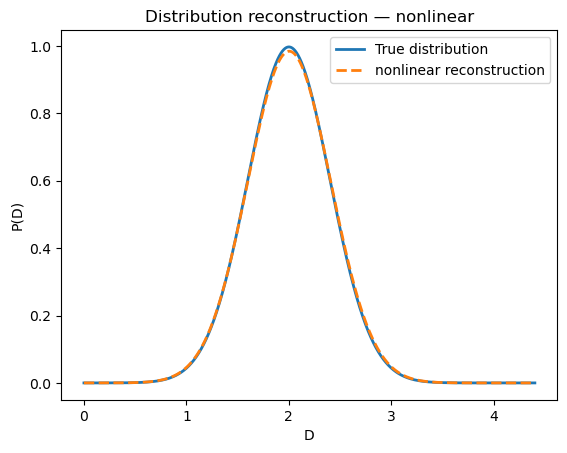

In [25]:
result_nonlinear = fit_cumulants_nonlinear(
    q_vals=q_vals,
    t_vals=t_vals,
    f_mat=f_noisy,
    n_cumulants=n_cumulants,
    f_min=f_min,
    f_max=f_max,
    sigma=None,
    absolute_sigma=False,
)

print_fit_summary(result_nonlinear, true_mu=mu_D, true_sigma=sigma_D)
plot_collapsed_fit(result_nonlinear)
plot_fit_vs_t(result_nonlinear, q_vals, t_vals, f_noisy)
plot_distribution_comparison(D_grid, P_grid, result_nonlinear)

In [17]:
comparison_df = compare_fit_results(
    result_linear,
    result_nonlinear,
    true_mu=mu_D,
    true_sigma=sigma_D,
)

comparison_df

,method,mu1,sigma,rmse,true_mu,abs_err_mu1,true_sigma,abs_err_sigma
0,linear,2.044206,0.833484,0.022556,2.0,0.044206,0.4,0.433484
1,nonlinear,2.008491,0.496259,0.005321,2.0,0.008491,0.4,0.096259


In [18]:
def scan_fmin_vs_parameters(
    q_vals,
    t_vals,
    f_mat,
    method="nonlinear",
    n_cumulants=4,
    fmin_grid=None,
    f_max=1.0,
):
    
    if fmin_grid is None:
        fmin_grid = np.arange(0.02, 0.31, 0.01)

    rows = []

    for f_min in fmin_grid:

        try:

            if method == "linear":
                result = fit_cumulants_linear(
                    q_vals=q_vals,
                    t_vals=t_vals,
                    f_mat=f_mat,
                    n_cumulants=n_cumulants,
                    f_min=f_min,
                    f_max=f_max,
                )

            elif method == "nonlinear":
                result = fit_cumulants_nonlinear(
                    q_vals=q_vals,
                    t_vals=t_vals,
                    f_mat=f_mat,
                    n_cumulants=n_cumulants,
                    f_min=f_min,
                    f_max=f_max,
                )

            mu1, mu2, sigma_rec = extract_mu_sigma(result)

            rows.append({
                "f_min": f_min,
                "mu1": mu1,
                "sigma_rec": sigma_rec,
                "rmse": result["rmse"],
                "n_points": len(result["x_data"]),
            })

        except Exception:

            rows.append({
                "f_min": f_min,
                "mu1": np.nan,
                "sigma_rec": np.nan,
                "rmse": np.nan,
                "n_points": 0,
            })

    return pd.DataFrame(rows)

In [19]:
fmin_grid = np.arange(0.02, 0.31, 0.01)

scan_df = scan_fmin_vs_parameters(
    q_vals=q_vals,
    t_vals=t_vals,
    f_mat=f_noisy,
    method="nonlinear",
    n_cumulants=n_cumulants,
    fmin_grid=fmin_grid,
    f_max=1.0,
)

scan_df.head()

,f_min,mu1,sigma_rec,rmse,n_points
0,0.02,2.017526,0.601355,0.006090,2814
1,0.03,2.013368,0.549755,0.005592,2731
2,0.04,2.011003,0.521747,0.005459,2687
3,0.05,2.009765,0.505117,0.005419,2656
4,0.06,2.007788,0.474183,0.005376,2623


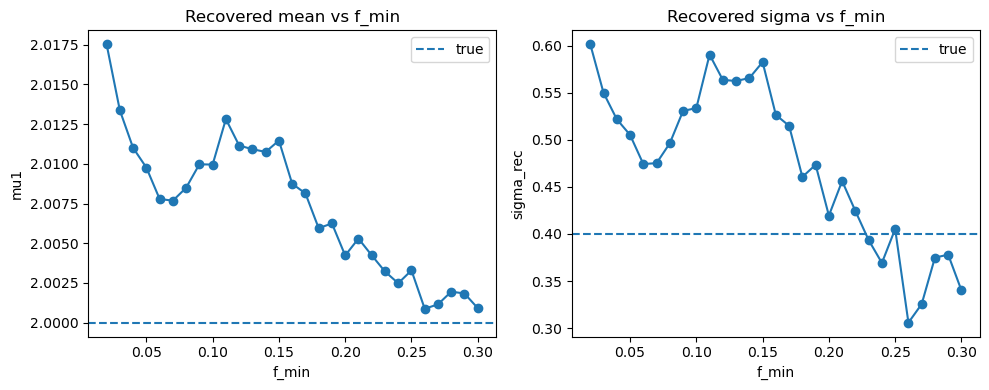

In [20]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(scan_df["f_min"], scan_df["mu1"], marker="o")
plt.axhline(mu_D, linestyle="--", label="true")
plt.xlabel("f_min")
plt.ylabel("mu1")
plt.title("Recovered mean vs f_min")
plt.legend()

plt.subplot(1,2,2)
plt.plot(scan_df["f_min"], scan_df["sigma_rec"], marker="o")
plt.axhline(sigma_D, linestyle="--", label="true")
plt.xlabel("f_min")
plt.ylabel("sigma_rec")
plt.title("Recovered sigma vs f_min")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
fmin_grid = np.arange(0.02, 0.31, 0.01)

scan_df = scan_fmin_vs_parameters(
    q_vals=q_vals,
    t_vals=t_vals,
    f_mat=f_noisy,
    method="linear",
    n_cumulants=n_cumulants,
    fmin_grid=fmin_grid,
    f_max=1.0,
)

scan_df.head()

,f_min,mu1,sigma_rec,rmse,n_points
0,0.02,0.203850,5.326960e-02,1.034548,2814
1,0.03,2.020591,2.604427e-12,0.049839,2731
2,0.04,2.093114,1.037535e+00,0.033493,2687
3,0.05,2.090726,1.046678e+00,0.029423,2656
4,0.06,2.061926,9.127888e-01,0.026184,2623


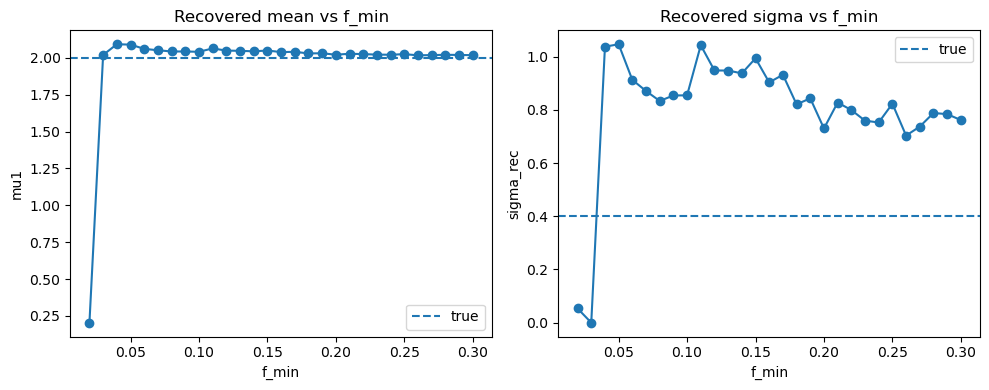

In [22]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(scan_df["f_min"], scan_df["mu1"], marker="o")
plt.axhline(mu_D, linestyle="--", label="true")
plt.xlabel("f_min")
plt.ylabel("mu1")
plt.title("Recovered mean vs f_min")
plt.legend()

plt.subplot(1,2,2)
plt.plot(scan_df["f_min"], scan_df["sigma_rec"], marker="o")
plt.axhline(sigma_D, linestyle="--", label="true")
plt.xlabel("f_min")
plt.ylabel("sigma_rec")
plt.title("Recovered sigma vs f_min")
plt.legend()

plt.tight_layout()
plt.show()